# Capstone Project: Cleaning and Transform Data
**Digital Wallet Transactions Dataset**

This dataset simulates transactions from a digital wallet platform similar to popular services like PayTm in India or Khalti in Nepal. It contains 5000 synthetic records of various financial transactions across multiple categories, providing a rich source for analysis of digital payment behaviors and trends.


**Description**:
- idx: Unique index for each record
- transaction_id:Unique identifier for each transaction (UUID)
- user_id: Unique identifier for each user
- transaction_date: Date and time of the transaction
- product_category: Category of the product or service
- product_name: Specific product or service name
- merchant_name: Name of the merchant or service provider
- product_amount: Transaction amount in local currency
- transaction_fee: Fee charged for the transaction
- cashback: Cashback amount received for the transaction
- loyalty_points: Loyalty points earned from the transaction
- payment_method: Method used for payment
- transaction_status: Status of the transaction (Successful, Failed, Pending)
- merchant_id: Unique identifier for each merchant
- device_type: Type of device used for the transaction
- location: Broad location category of the transaction

## Import Library

In [ ]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta

In [ ]:
# setting tampilan
pd.set_option('display.max_columns', None)

## Gathering Data
Load data from .csv

In [ ]:
# =========================================================
# GATHERING DATA
# =========================================================

df = pd.read_csv('data_clean_balanced.csv')

print("Jumlah data:", len(df))

df.head()


# =========================================================
# ASSESSING DATA
# =========================================================

# informasi dataset
df.info()


# cek missing value
print("\n===== MISSING VALUE =====")
print(df.isna().sum())


# cek duplicate
print("\n===== DUPLICATE =====")
print(df.duplicated().sum())


# statistik deskriptif
print("\n===== DESCRIBE =====")
display(df.describe(include='all'))

Jumlah data: 7164
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7164 entries, 0 to 7163
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   idx                4913 non-null   float64
 1   id_transaksi       7164 non-null   object 
 2   user_id            4913 non-null   object 
 3   tanggal            7164 non-null   object 
 4   kategori           7164 non-null   object 
 5   nama_produk        4913 non-null   object 
 6   nama_merchant      4913 non-null   object 
 7   harga_produk       7164 non-null   int64  
 8   biaya_admin        7164 non-null   int64  
 9   cashback           7164 non-null   int64  
 10  poin_loyalitas     4913 non-null   float64
 11  metode_pembayaran  7164 non-null   object 
 12  status_transaksi   7164 non-null   object 
 13  id_merchant        4913 non-null   object 
 14  tipe_perangkat     4913 non-null   object 
 15  lokasi             7164 non-null   object 
 16  bulan 

,idx,id_transaksi,user_id,tanggal,kategori,nama_produk,nama_merchant,harga_produk,biaya_admin,cashback,poin_loyalitas,metode_pembayaran,status_transaksi,id_merchant,tipe_perangkat,lokasi,bulan,hari,nama_transaksi
count,4913.000000,7164,4913,7164,7164,4913,4913,7.164000e+03,7164.000000,7164.000000,4913.000000,7164,7164,4913,4913,7164,4913,4913,7164
unique,NaN,5079,3072,5067,8,99,97,NaN,NaN,NaN,NaN,6,3,968,3,3,12,7,1516
top,NaN,SYN-0477,USER_08354,2026-02-25 11:44:33.197826,Hiburan,Python Programming Course,Flipkart,NaN,NaN,NaN,NaN,Transfer Bank,Berhasil,MERCH_0480,Android,Perkotaan,Desember,Rabu,Naik Ojek Online
freq,NaN,7,8,7,900,143,179,NaN,NaN,NaN,NaN,1623,6918,18,2988,4226,456,732,119
mean,2495.163647,NaN,NaN,NaN,NaN,NaN,NaN,5.111114e+05,2765.973897,6360.673925,496.200692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1437.067130,NaN,NaN,NaN,NaN,NaN,NaN,3.653031e+05,1611.446385,3742.572233,289.983683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.150000e+03,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1250.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.882250e+05,1377.000000,3165.000000,241.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2478.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.383415e+05,2735.000000,6328.000000,506.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3738.000000,NaN,NaN,NaN,NaN,NaN,NaN,8.195392e+05,4173.750000,9387.500000,748.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Assessing Data

In [ ]:
# =========================================================
# CEK KATEGORI UNIK
# =========================================================

print("\n===== KATEGORI =====")
print(df['kategori'].unique())

print("\n===== STATUS TRANSAKSI =====")
print(df['status_transaksi'].unique())

print("\n===== METODE PEMBAYARAN =====")
print(df['metode_pembayaran'].unique())

print("\n===== LOKASI =====")
print(df['lokasi'].unique())


# =========================================================
# CEK DATA ANEH / TIDAK MASUK AKAL
# =========================================================

# nominal negatif
print("\n===== HARGA NEGATIF =====")
print((df['harga_produk'] < 0).sum())

print("\n===== BIAYA ADMIN NEGATIF =====")
print((df['biaya_admin'] < 0).sum())

print("\n===== CASHBACK NEGATIF =====")
print((df['cashback'] < 0).sum())


# cashback lebih besar dari harga
print("\n===== CASHBACK > HARGA =====")
display(df[df['cashback'] > df['harga_produk']])


===== KATEGORI =====
['Hiburan' 'Tagihan' 'Hadiah & Amal' 'Belanja' 'Tabungan & Investasi'
 'Pendidikan' 'Makanan & Minuman' 'Transportasi']

===== STATUS TRANSAKSI =====
['Berhasil' 'Pending' 'Gagal']

===== METODE PEMBAYARAN =====
['UPI' 'Saldo Dompet' 'QRIS' 'Kartu Debit' 'Transfer Bank' 'Kartu Kredit']

===== LOKASI =====
['Perkotaan' 'Pinggiran Kota' 'Pedesaan']

===== HARGA NEGATIF =====
0

===== BIAYA ADMIN NEGATIF =====
0

===== CASHBACK NEGATIF =====
0

===== CASHBACK > HARGA =====


,idx,id_transaksi,user_id,tanggal,kategori,nama_produk,nama_merchant,harga_produk,biaya_admin,cashback,poin_loyalitas,metode_pembayaran,status_transaksi,id_merchant,tipe_perangkat,lokasi,bulan,hari,nama_transaksi
98,1189.0,a316f785-be6b-4bb7-b0e2-88a3c41feec4,USER_00702,2023-11-14 21:35:00.000000,Transportasi,Share Ride,Meru,6403,266,6562,520.0,Saldo Dompet,Berhasil,MERCH_0436,iOS,Perkotaan,November,Selasa,Naik Ojek Online
209,NaN,SYN-1357,NaN,2026-03-31 11:44:33.204572,Makanan & Minuman,NaN,NaN,10755,582,12194,NaN,Saldo Dompet,Berhasil,NaN,NaN,Pinggiran Kota,NaN,NaN,jajan siomay lagi
524,797.0,efd2d6b6-0881-40d5-a113-2362c801745f,USER_02340,2023-10-15 02:56:00.000000,Tagihan,Prepaid Plan 399,BSNL,1622,5253,8488,809.0,UPI,Berhasil,MERCH_0849,iOS,Perkotaan,Oktober,Minggu,bayar telkom
625,4520.0,6339ea6c-961f-49d9-bbcb-536c8fb0ad01,USER_04788,2024-07-16 16:23:00.000000,Tabungan & Investasi,Car Loan Installment,HDFC Bank,1340,4291,8091,268.0,Kartu Kredit,Berhasil,MERCH_0513,Android,Pedesaan,Juli,Selasa,top up sbi sekuritas
800,1377.0,43712420-3cac-4a5b-8233-bd377379d9fe,USER_02895,2023-11-29 04:52:00.000000,Tagihan,Commercial Bill,BSES,8544,1297,10771,278.0,Saldo Dompet,Berhasil,MERCH_0299,Android,Perkotaan,November,Rabu,isi pulsa xl
932,NaN,SYN-1357,NaN,2026-03-31 11:44:33.204572,Makanan & Minuman,NaN,NaN,10755,582,12194,NaN,Saldo Dompet,Berhasil,NaN,NaN,Pinggiran Kota,NaN,NaN,bayar traktir temen makan
1117,89.0,46447c57-cf75-4128-8487-802e3111104c,USER_06578,2023-08-24 06:02:00.000000,Transportasi,Volvo Multi-Axle,Goibibo,1466,4140,2114,271.0,Kartu Kredit,Berhasil,MERCH_0924,Web,Perkotaan,Agustus,Kamis,bayar parkir mall
1228,2693.0,c2447648-9975-4eca-8c64-2b2684f90dde,USER_01206,2024-03-05 01:38:00.000000,Pendidikan,Python Programming Course,BYJU'S,3224,5129,9317,123.0,Kartu Kredit,Berhasil,MERCH_0519,Android,Perkotaan,Maret,Selasa,bayar seminar
1500,1732.0,e5fc7e6e-82c9-4bc9-a2d8-7885bf93c7f0,USER_05962,2023-12-24 01:08:00.000000,Belanja,Laptop Backpack,Snapdeal,2696,4245,8948,78.0,Saldo Dompet,Berhasil,MERCH_0030,Web,Perkotaan,Desember,Minggu,beli sendok garpu
1624,3243.0,cb3670c9-e764-41b2-8daa-34bc070edc30,USER_02246,2024-04-15 11:37:00.000000,Belanja,Dairy Milk Chocolate,BigBasket,2239,5583,11112,63.0,UPI,Berhasil,MERCH_0467,Android,Perkotaan,April,Senin,checkout di shopee beauty


## Cleaning Data

In [ ]:
# =========================================================
# DATA CLEANING
# =========================================================

# ---------------------------------------------------------
# Hapus Duplicate
# ---------------------------------------------------------

df.drop_duplicates(inplace=True)

print("\nJumlah data setelah hapus duplicate:", len(df))


# ---------------------------------------------------------
# Menangani Missing Value
# ---------------------------------------------------------

# isi missing value kategori object
kolom_object = df.select_dtypes(include='object').columns

for col in kolom_object:
    df[col] = df[col].fillna('Tidak Diketahui')

# isi missing value numerik
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns

for col in kolom_numerik:
    df[col] = df[col].fillna(0)

print("\n===== MISSING VALUE SETELAH CLEANING =====")
print(df.isna().sum())


# =========================================================
# TRANSFORMASI DATA
# =========================================================

# ---------------------------------------------------------
# Konversi Kolom Tanggal
# ---------------------------------------------------------

df['tanggal'] = pd.to_datetime(df['tanggal'])

# buat kolom tambahan
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month_name()
df['hari'] = df['tanggal'].dt.day_name()

# translate bulan
bulan_map = {
    'January': 'Januari',
    'February': 'Februari',
    'March': 'Maret',
    'April': 'April',
    'May': 'Mei',
    'June': 'Juni',
    'July': 'Juli',
    'August': 'Agustus',
    'September': 'September',
    'October': 'Oktober',
    'November': 'November',
    'December': 'Desember'
}

df['bulan'] = df['bulan'].map(bulan_map)

# translate hari
hari_map = {
    'Monday': 'Senin',
    'Tuesday': 'Selasa',
    'Wednesday': 'Rabu',
    'Thursday': 'Kamis',
    'Friday': 'Jumat',
    'Saturday': 'Sabtu',
    'Sunday': 'Minggu'
}

df['hari'] = df['hari'].map(hari_map)


# ---------------------------------------------------------
# Rapikan Tipe Data
# ---------------------------------------------------------

kolom_integer = [
    'harga_produk',
    'biaya_admin',
    'cashback'
]

for col in kolom_integer:
    df[col] = df[col].astype(int)


# ---------------------------------------------------------
# Standardisasi Teks
# ---------------------------------------------------------

kolom_text = [
    'kategori',
    'nama_transaksi',
    'metode_pembayaran',
    'status_transaksi',
    'lokasi'
]

for col in kolom_text:
    df[col] = df[col].astype(str).str.strip()


# =========================================================
# VALIDASI HASIL CLEANING
# =========================================================

print("\n===== SAMPLE DATA =====")
display(df.head())

print("\n===== INFO DATA =====")
df.info()

print("\n===== DISTRIBUSI KATEGORI =====")
print(df['kategori'].value_counts())

print("\n===== JUMLAH FINAL =====")
print(len(df))


# =========================================================
# SORT DATA
# =========================================================

df = df.sort_values(
    by='tanggal',
    ascending=False
)


Jumlah data setelah hapus duplicate: 7153

===== MISSING VALUE SETELAH CLEANING =====
idx                  0
id_transaksi         0
user_id              0
tanggal              0
kategori             0
nama_produk          0
nama_merchant        0
harga_produk         0
biaya_admin          0
cashback             0
poin_loyalitas       0
metode_pembayaran    0
status_transaksi     0
id_merchant          0
tipe_perangkat       0
lokasi               0
bulan                0
hari                 0
nama_transaksi       0
dtype: int64

===== SAMPLE DATA =====


,idx,id_transaksi,user_id,tanggal,kategori,nama_produk,nama_merchant,harga_produk,biaya_admin,cashback,poin_loyalitas,metode_pembayaran,status_transaksi,id_merchant,tipe_perangkat,lokasi,bulan,hari,nama_transaksi,tahun
0,4176.0,d7573f07-7bfe-4816-a249-d7fd4414e75c,USER_04681,2024-06-21 00:14:00.000000,Hiburan,Baahubali 2,Carnival Cinemas,420693,4180,7275,579.0,UPI,Berhasil,MERCH_0785,Web,Perkotaan,Juni,Jumat,bayar hooq,2024
1,1495.0,af252767-4d2e-4824-8123-17848b061b5e,USER_00468,2023-12-07 04:07:00.000000,Tagihan,Industrial Bill,MSEDCL,157248,3643,448,260.0,UPI,Berhasil,MERCH_0752,Android,Perkotaan,Desember,Kamis,bayar gas,2023
2,947.0,e43e1696-575b-4b3f-a163-42c87d89368a,USER_09824,2023-10-27 01:25:00.000000,Hadiah & Amal,Rs. 250 Coffee Shop Card,Lifestyle,273348,3482,4994,213.0,Saldo Dompet,Berhasil,MERCH_0226,Android,Perkotaan,Oktober,Jumat,beli parfum buat kado bokap,2023
3,0.0,SYN-1487,Tidak Diketahui,2026-03-09 11:44:33.205551,Belanja,Tidak Diketahui,Tidak Diketahui,219482,3564,12145,0.0,QRIS,Berhasil,Tidak Diketahui,Tidak Diketahui,Pinggiran Kota,Maret,Senin,belanja keperluan kos,2026
4,3461.0,d5a4bca7-77d0-4cb6-8571-d87aaf4f6a76,USER_03672,2024-05-01 18:13:00.000000,Tabungan & Investasi,Personal Loan Payment,Bajaj Finserv,1101634,2108,6040,548.0,Saldo Dompet,Berhasil,MERCH_0051,Android,Perkotaan,Mei,Rabu,top up di ipot,2024



===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
Index: 7153 entries, 0 to 7163
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   idx                7153 non-null   float64       
 1   id_transaksi       7153 non-null   object        
 2   user_id            7153 non-null   object        
 3   tanggal            7153 non-null   datetime64[ns]
 4   kategori           7153 non-null   object        
 5   nama_produk        7153 non-null   object        
 6   nama_merchant      7153 non-null   object        
 7   harga_produk       7153 non-null   int64         
 8   biaya_admin        7153 non-null   int64         
 9   cashback           7153 non-null   int64         
 10  poin_loyalitas     7153 non-null   float64       
 11  metode_pembayaran  7153 non-null   object        
 12  status_transaksi   7153 non-null   object        
 13  id_merchant        7153 non-null   object    

In [ ]:
# SIMPAN HASIL CLEANING
df.to_csv('data_wrangling_final.csv', index=False)

df.to_json('data_wrangling_final.json', orient='records')

print("\nData berhasil disimpan!")


Data berhasil disimpan!


In [ ]:
transaksi_user = (
    df.groupby('user_id')
    .agg(
        total_transaksi=(
            'harga_produk',
            'count'
        ),
        total_pengeluaran=(
            'harga_produk',
            'sum'
        )
    )
)

transaksi_user = transaksi_user.sort_values(
    by='total_transaksi',
    ascending=False
)

display(
    transaksi_user.head(10)
)

selected_user = transaksi_user.index[0]

print(
    "User dipilih:",
    selected_user
)

df = df[
    df['user_id']
    ==
    selected_user
].copy()

print(
    "Jumlah data:",
    len(df)
)

,total_transaksi,total_pengeluaran
user_id,,
Tidak Diketahui,2246,911826996
USER_08354,8,717744
USER_04724,8,7088248
USER_07477,7,2986401
USER_00399,7,1158318
USER_09019,7,3142352
USER_03191,6,1863128
USER_07085,6,1653018
USER_06210,6,3469365


User dipilih: Tidak Diketahui
Jumlah data: 2246


In [ ]:
# =========================================================
# NORMALISASI NOMINAL AGAR REALISTIS
# =========================================================

print(
    "Sebelum scaling:"
)

print(
    df['harga_produk'].describe()
)

# turunkan nominal
scaling_factor = 0.03

df['harga_produk'] = (
    df['harga_produk']
    * scaling_factor
).astype(int)

df['biaya_admin'] = (
    df['biaya_admin']
    * scaling_factor
).astype(int)

df['cashback'] = (
    df['cashback']
    * scaling_factor
).astype(int)

print(
    "Sesudah scaling:"
)

print(
    df['harga_produk'].describe()
)

Sebelum scaling:
count    2.246000e+03
mean     4.059782e+05
std      4.185149e+05
min      1.023800e+04
25%      1.102242e+05
50%      2.184685e+05
75%      6.331750e+05
max      1.485143e+06
Name: harga_produk, dtype: float64
Sesudah scaling:
count     2246.000000
mean     12178.841941
std      12555.449517
min        307.000000
25%       3306.500000
50%       6554.000000
75%      18995.000000
max      44554.000000
Name: harga_produk, dtype: float64


In [ ]:
cek_bulanan = df.groupby(
    ['tahun','bulan']
)['harga_produk'].sum()

display(cek_bulanan)

tahun  bulan   
2026   April       9170178
       Februari    4894634
       Maret       9148155
       Mei         4140712
Name: harga_produk, dtype: int64

In [ ]:
batas_kategori = {
    'Makanan & Minuman': 200000,
    'Transportasi': 100000,
    'Belanja': 1000000,
    'Hiburan': 300000,
    'Tagihan': 1500000,
    'Pendidikan': 2000000,
    'Tabungan & Investasi': 3000000
}

for kategori, batas in batas_kategori.items():

    mask = df['kategori'] == kategori

    df.loc[
        mask,
        'harga_produk'
    ] = np.clip(
        df.loc[
            mask,
            'harga_produk'
        ],
        1000,
        batas
    )

In [ ]:
# =========================================================
# VALIDASI NOMINAL
# =========================================================

harian_check = (
    df.groupby(
        df['tanggal'].dt.date
    )['harga_produk']
    .sum()
)

print(
    "Rata-rata per hari:"
)

print(
    harian_check.mean()
)

print(
    "Maksimum per hari:"
)

print(
    harian_check.max()
)

Rata-rata per hari:
300928.8241758242
Maksimum per hari:
707000


In [ ]:
print(
    df[['user_id','tanggal','harga_produk']]
    .head()
)

print(
    "Jumlah baris:"
)

print(len(df))

print(
    "User unik:"
)

print(
    df['user_id']
    .nunique()
)

              user_id                    tanggal  harga_produk
6651  Tidak Diketahui 2026-05-13 11:44:33.205306         21479
6396  Tidak Diketahui 2026-05-13 11:44:33.205167          4167
4218  Tidak Diketahui 2026-05-13 11:44:33.203319          1970
5534  Tidak Diketahui 2026-05-13 11:44:33.203319          1970
942   Tidak Diketahui 2026-05-13 11:44:33.203319          1970
Jumlah baris:
2246
User unik:
1


In [ ]:
# cek nominal masuk akal
harian_check = (
    df.groupby(
        df['tanggal'].dt.date
    )['harga_produk']
    .sum()
)

print(
    "Rata-rata per hari:"
)

print(
    harian_check.mean()
)

print(
    "Pengeluaran maksimum per hari:"
)

print(
    harian_check.max()
)

Rata-rata per hari:
300928.8241758242
Pengeluaran maksimum per hari:
707000


## Pertanyaan Bisnis

- Berapa total pengeluaran pengguna bulan Mei 2026 dibandingkan April 2026, dan kategori apa yang mengalami kenaikan persentase pengeluaran tertinggi?
- Berapa persentase pengeluaran tiap kategori dari total pengeluaran pada Mei 2026, dan kategori mana yang memiliki frekuensi transaksi tertinggi dan total nominal terbesar?
- Bagaimana tren total pengeluaran harian pengguna selama 30 hari terakhir, dan pada hari apa saja terjadi lonjakan pengeluaran?

## Exploratory Data Analysis

### Explore Pengeluaran per Bulan

In [ ]:
# Total pengeluaran per bulan
pengeluaran_bulanan = df.groupby(
    ['tahun', 'bulan']
).agg({
    'harga_produk': ['sum', 'mean', 'count']
})

display(pengeluaran_bulanan.sort_index())

harga_produk                    
                        sum          mean count
tahun bulan                                    
2026  April         9179569  12046.678478   762
      Februari      4899987  12219.418953   401
      Maret         9159240  12212.320000   750
      Mei           4145727  12449.630631   333

#### Insight:
- Total pengeluaran menunjukkan adanya perbedaan aktivitas transaksi pada setiap bulan.
- Nilai rata-rata transaksi (mean) membantu melihat apakah pengguna melakukan transaksi kecil namun sering atau transaksi besar dengan frekuensi rendah.
- Jumlah transaksi (count) menunjukkan tingkat aktivitas penggunaan digital wallet.
- Perbandingan April dan Mei 2026 menjadi dasar untuk mengidentifikasi perubahan perilaku pengeluaran pengguna.

### Explore Pengeluaran per Kategori

In [ ]:
pengeluaran_kategori = df.groupby(
    'kategori'
).agg(
    total_pengeluaran=('harga_produk','sum'),
    rata_rata=('harga_produk','mean'),
    jumlah_transaksi=('harga_produk','count')
).sort_values(
    by='total_pengeluaran',
    ascending=False
)

display(pengeluaran_kategori)

,total_pengeluaran,rata_rata,jumlah_transaksi
kategori,,,
Tabungan & Investasi,9803710,23013.403756,426
Pendidikan,9423519,25062.550532,376
Tagihan,2106221,23145.285714,91
Hadiah & Amal,1845326,4556.360494,405
Makanan & Minuman,1703180,4290.125945,397
Belanja,1069205,4400.020576,243
Transportasi,813766,4786.858824,170
Hiburan,619596,4489.826087,138


### Insight
- Setiap kategori memiliki kontribusi pengeluaran yang berbeda terhadap total transaksi.
- Kategori dengan total nominal tertinggi menunjukkan area pengeluaran utama pengguna.
- Jumlah transaksi membantu mengidentifikasi kategori yang paling sering digunakan.
- Perbedaan antara frekuensi dan nominal dapat menunjukkan bahwa beberapa kategori memiliki transaksi kecil tetapi sering dilakukan.

### Explore Transaksi Harian

In [ ]:
harian_df = df.groupby(
    df['tanggal'].dt.date
).agg(
    total_pengeluaran=('harga_produk','sum'),
    jumlah_transaksi=('harga_produk','count')
)

display(harian_df.head())

,total_pengeluaran,jumlah_transaksi
tanggal,,
2026-02-12,331900,27
2026-02-13,213383,24
2026-02-14,330094,22
2026-02-15,218349,16
2026-02-16,202557,20


#### Insight
- Pengeluaran harian menunjukkan pola aktivitas finansial pengguna dari waktu ke waktu.
- Variasi jumlah transaksi per hari dapat mengindikasikan perubahan kebutuhan pengguna.
- Data ini membantu mendeteksi hari dengan aktivitas tinggi maupun rendah.
- Informasi ini digunakan untuk analisis lonjakan pengeluaran pada pertanyaan bisnis ketiga.

## Visualisasi

### Pertanyaan 1
Berapa total pengeluaran pengguna bulan Mei 2026 dibandingkan April 2026, dan kategori apa yang mengalami kenaikan persentase pengeluaran tertinggi?

In [ ]:
#Hitung total pengeluaran April dan Mei
bulan_compare = df[
    (df['tahun'] == 2026) &
    (df['bulan'].isin(['April','Mei']))
]

total_bulanan = bulan_compare.groupby(
    'bulan'
).agg(
    total_pengeluaran=('harga_produk','sum')
).reset_index()

display(total_bulanan)

,bulan,total_pengeluaran
0,April,9179569
1,Mei,4145727


#### Insight
- Tabel menunjukkan total nominal pengeluaran pengguna pada April dan Mei 2026.
- Jika total Mei lebih besar dari April maka terjadi peningkatan aktivitas transaksi pengguna.
- Jika total Mei lebih kecil maka terjadi penurunan pengeluaran pada bulan berikutnya.
- Selisih kedua bulan dapat digunakan untuk mengukur pertumbuhan pengeluaran bulanan.

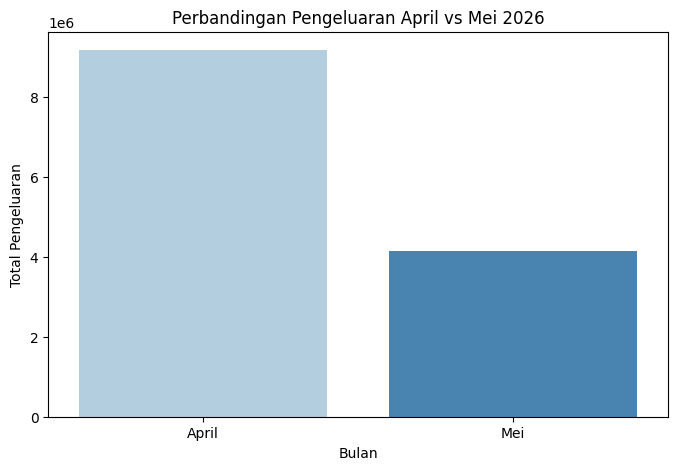

In [ ]:
#Visualsasi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=total_bulanan,
    x='bulan',
    y='total_pengeluaran',
    hue='bulan',
    palette='Blues',
    legend=False
)

plt.title(
    'Perbandingan Pengeluaran April vs Mei 2026'
)

plt.xlabel('Bulan')
plt.ylabel('Total Pengeluaran')

plt.show()

#### Insight
- Grafik memperlihatkan perbandingan total pengeluaran antara April dan Mei secara visual.
- Batang yang lebih tinggi menunjukkan bulan dengan aktivitas transaksi lebih besar.
- Perubahan tinggi batang menunjukkan adanya peningkatan atau penurunan perilaku konsumsi pengguna.
- Hasil ini dapat digunakan untuk mengevaluasi perubahan kebiasaan transaksi dari bulan sebelumnya.

In [ ]:
kategori_growth = bulan_compare.pivot_table(
    index='kategori',
    columns='bulan',
    values='harga_produk',
    aggfunc='sum',
    fill_value=0
)

kategori_growth = kategori_growth.reindex(
    columns=['April', 'Mei'],
    fill_value=0
)

kategori_growth['persentase_kenaikan'] = (
    (
        kategori_growth['Mei']
        -
        kategori_growth['April']
    )
    /
    kategori_growth['April'].replace(
        0,
        np.nan
    )
) * 100

kategori_growth = kategori_growth.sort_values(
    'persentase_kenaikan',
    ascending=False
)

display(kategori_growth)

bulan,April,Mei,persentase_kenaikan
kategori,,,
Pendidikan,2877216,1478854,-48.601217
Transportasi,247857,124563,-49.744006
Hadiah & Amal,683803,320768,-53.090583
Tabungan & Investasi,3421126,1544508,-54.853811
Hiburan,198512,84707,-57.329028
Belanja,362200,135330,-62.636665
Makanan & Minuman,660442,219892,-66.705328
Tagihan,728413,237105,-67.449098


#### Insight
- Persentase kenaikan menunjukkan kategori yang mengalami pertumbuhan tercepat dari April ke Mei.
- Kategori dengan nilai persentase tertinggi menjadi indikator perubahan prioritas pengeluaran pengguna.
- Nilai negatif menunjukkan adanya penurunan pengeluaran pada kategori tertentu.
- Informasi ini membantu menentukan kategori yang mengalami peningkatan permintaan.

## Pertanyaan 2
Berapa persentase pengeluaran tiap kategori dari total pengeluaran pada Mei 2026, dan kategori mana yang memiliki frekuensi transaksi tertinggi dan total nominal terbesar?

In [ ]:
mei_df = df[
    (df['tahun']==2026) &
    (df['bulan']=='Mei')
]

In [ ]:
# Hitung persentase pengeluaran
kategori_mei = mei_df.groupby(
    'kategori'
).agg(
    total_pengeluaran=('harga_produk','sum'),
    frekuensi=('harga_produk','count')
)

total_mei = kategori_mei[
    'total_pengeluaran'
].sum()

kategori_mei[
    'persentase'
] = (
    kategori_mei[
        'total_pengeluaran'
    ]
    /
    total_mei
) * 100

kategori_mei = kategori_mei.sort_values(
    by='total_pengeluaran',
    ascending=False
)

display(kategori_mei)

,total_pengeluaran,frekuensi,persentase
kategori,,,
Tabungan & Investasi,1544508,66,37.255420
Pendidikan,1478854,55,35.671765
Hadiah & Amal,320768,61,7.737316
Tagihan,237105,10,5.719262
Makanan & Minuman,219892,61,5.304064
Belanja,135330,35,3.264325
Transportasi,124563,26,3.004612
Hiburan,84707,19,2.043236


#### Insight
- Total pengeluaran menunjukkan kategori dengan kontribusi nominal terbesar selama Mei 2026.
- Frekuensi transaksi menunjukkan kategori yang paling sering digunakan pengguna.
- Persentase membantu melihat kontribusi masing-masing kategori terhadap total pengeluaran bulan Mei.
- Kategori dengan nominal besar belum tentu memiliki frekuensi transaksi tinggi.

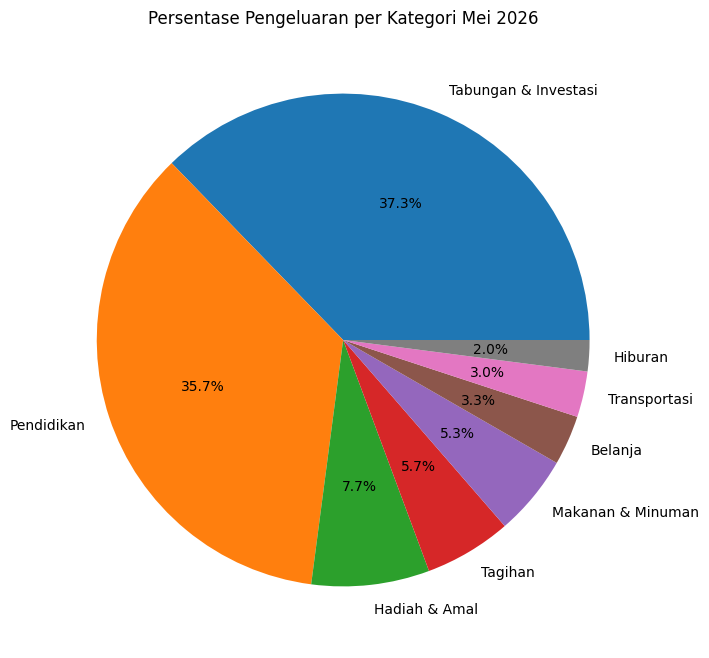

In [ ]:
# Visualisasi Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    kategori_mei['persentase'],
    labels=kategori_mei.index,
    autopct='%1.1f%%'
)

plt.title(
    'Persentase Pengeluaran per Kategori Mei 2026'
)

plt.show()

#### Insight
- Diagram pie memperlihatkan proporsi pengeluaran tiap kategori pada Mei 2026.
- Bagian terbesar menunjukkan kategori dominan dalam penggunaan dana pengguna.
- Distribusi yang merata menunjukkan pengeluaran tersebar pada beberapa kategori.
- Distribusi yang tidak merata menunjukkan konsentrasi pengeluaran pada kategori tertentu.

In [ ]:
# Frekuensi transaksi tertinggi
frekuensi_tertinggi = kategori_mei.sort_values(
    by='frekuensi',
    ascending=False
)

display(frekuensi_tertinggi)

,total_pengeluaran,frekuensi,persentase
kategori,,,
Tabungan & Investasi,1544508,66,37.255420
Hadiah & Amal,320768,61,7.737316
Makanan & Minuman,219892,61,5.304064
Pendidikan,1478854,55,35.671765
Belanja,135330,35,3.264325
Transportasi,124563,26,3.004612
Hiburan,84707,19,2.043236
Tagihan,237105,10,5.719262


#### Insight
- Frekuensi transaksi memperlihatkan kategori yang paling aktif digunakan.
- Kategori dengan jumlah transaksi tinggi dapat menjadi layanan utama pengguna digital wallet.
- Perbandingan antara frekuensi dan total nominal membantu membedakan transaksi rutin dan transaksi bernilai besar.
- Informasi ini berguna untuk menentukan kategori prioritas bisnis.

### Pertanyaan 3
Bagaimana tren total pengeluaran harian pengguna selama 30 hari terakhir, dan pada hari apa saja terjadi lonjakan pengeluaran?

In [ ]:
tanggal_akhir = df[
    'tanggal'
].max()

tanggal_awal = (
    tanggal_akhir -
    pd.Timedelta(days=30)
)

last30 = df[
    df['tanggal'] >= tanggal_awal
]

In [ ]:
# Hitung penegluaran harian
harian = last30.groupby(
    last30['tanggal'].dt.date
).agg(
    total_pengeluaran=(
        'harga_produk',
        'sum'
    )
).reset_index()

display(harian.head())

,tanggal,total_pengeluaran
0,2026-04-13,80997
1,2026-04-14,283538
2,2026-04-15,396907
3,2026-04-16,413562
4,2026-04-17,273107


#### Insight
- Data harian memperlihatkan perubahan pengeluaran pengguna dari hari ke hari.
- Nilai total yang tinggi menunjukkan aktivitas transaksi lebih besar pada tanggal tertentu.
- Variasi harian dapat digunakan untuk mendeteksi pola konsumsi pengguna.
- Data ini menjadi dasar identifikasi lonjakan pengeluaran.

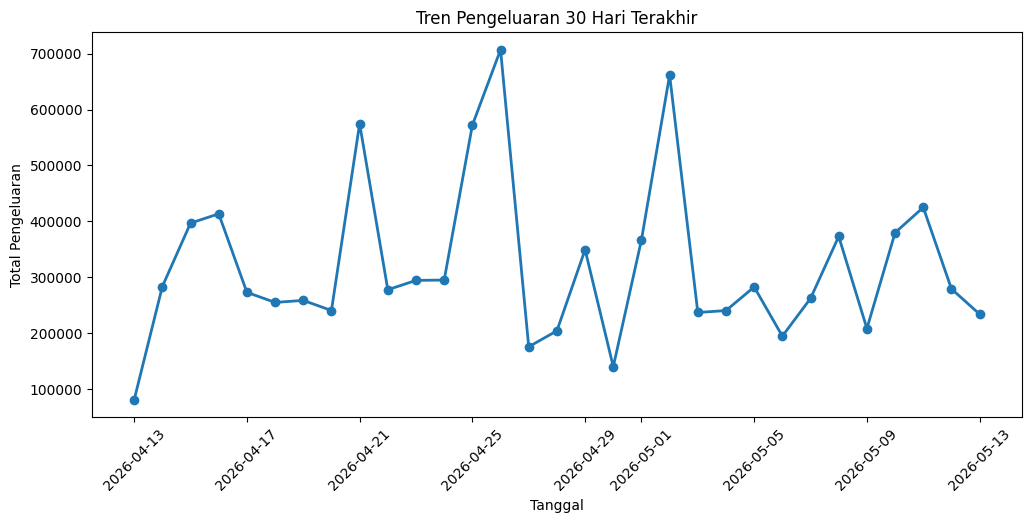

In [ ]:
# Visualisasi Tren
plt.figure(figsize=(12,5))

plt.plot(
    harian['tanggal'],
    harian['total_pengeluaran'],
    marker='o',
    linewidth=2
)

plt.title(
    'Tren Pengeluaran 30 Hari Terakhir'
)

plt.xlabel('Tanggal')
plt.ylabel('Total Pengeluaran')

plt.xticks(rotation=45)

plt.show()

#### Insight
- Grafik menunjukkan tren pengeluaran selama 30 hari terakhir.
- Kenaikan garis menunjukkan peningkatan aktivitas transaksi.
- Penurunan garis menunjukkan berkurangnya pengeluaran pengguna.
- Titik puncak pada grafik dapat menjadi indikasi periode konsumsi tinggi.

In [ ]:
# Deteksi lonjakan pengeluaran
threshold = (
    harian[
        'total_pengeluaran'
    ].mean()
    +
    harian[
        'total_pengeluaran'
    ].std()
)

lonjakan = harian[
    harian[
        'total_pengeluaran'
    ] > threshold
]

display(lonjakan)

,tanggal,total_pengeluaran
8,2026-04-21,574693
12,2026-04-25,572099
13,2026-04-26,707000
19,2026-05-02,661837


#### Insight
- Tanggal yang muncul merupakan hari dengan total pengeluaran di atas rata-rata normal.
- Lonjakan terjadi ketika nilai pengeluaran melebihi batas rata-rata ditambah standar deviasi.
- Hari-hari tersebut menunjukkan aktivitas finansial yang lebih tinggi dibanding periode lain.
- Informasi ini dapat digunakan untuk analisis perilaku pengguna dan strategi promosi.

## Conclusion

###1. Conclusion Pertanyaan 1

Total pengeluaran pengguna pada April dan Mei 2026 menunjukkan adanya perubahan aktivitas transaksi bulanan. Perbandingan kedua bulan memperlihatkan apakah pengguna meningkatkan atau menurunkan pengeluarannya pada Mei 2026. Analisis kenaikan persentase kategori menunjukkan kategori yang mengalami pertumbuhan paling tinggi sehingga dapat menggambarkan perubahan prioritas konsumsi pengguna.

####2. Conclusion Pertanyaan 2
Distribusi pengeluaran Mei 2026 menunjukkan bahwa tidak semua kategori memiliki kontribusi yang sama terhadap total transaksi. Beberapa kategori mendominasi total nominal pengeluaran, sedangkan kategori lain lebih sering digunakan meskipun nominal transaksinya lebih kecil. Hal ini menunjukkan adanya perbedaan antara intensitas penggunaan dan nilai transaksi.

###3. Conclusion Pertanyaan 3
Tren pengeluaran selama 30 hari terakhir menunjukkan pola aktivitas finansial pengguna yang berubah dari waktu ke waktu. Terdapat beberapa hari dengan lonjakan pengeluaran yang lebih tinggi dibanding rata-rata harian. Periode tersebut dapat digunakan untuk memahami perilaku pengguna dan menentukan waktu yang tepat untuk strategi promosi maupun penawaran layanan.

## Recommendation

1. Fokuskan promosi pada kategori yang mengalami kenaikan pengeluaran tertinggi karena menunjukkan peningkatan minat pengguna.
2. Kategori dengan frekuensi transaksi tinggi dapat diprioritaskan untuk program cashback atau loyalty agar meningkatkan retensi pengguna.
3. Analisis hari dengan lonjakan pengeluaran dapat dimanfaatkan untuk menentukan waktu kampanye pemasaran dan promo khusus.
4. Monitoring tren bulanan perlu dilakukan untuk mengidentifikasi perubahan perilaku transaksi pengguna secara lebih cepat.
5. Evaluasi kategori dengan penurunan pengeluaran untuk mengetahui kemungkinan perubahan kebutuhan pengguna.